# 07 – SageMaker Studio & CloudWatch Monitoring
## Semiconductor Yield Intelligence - AWS Native Observability

### 🎯 Objective

Set up native AWS monitoring using SageMaker Studio and CloudWatch for the ML pipeline.

This notebook will:
- Install required AWS and monitoring libraries
- Configure CloudWatch metrics for SageMaker training jobs
- Monitor SageMaker endpoints and inference performance
- Create CloudWatch dashboards for ML infrastructure
- Set up alarms for model degradation and infrastructure issues
- Track costs and resource utilization

### 📝 Project Configuration

**Feature Store (Created):**
- Feature Group Name: `wafer-features-1771819119`
- Created with defect_density, spatial_pattern, class_label features

**AWS S3 Paths:**
- S3 Bucket: `sagemaker-wafer-us-east-1-758553702243`
- S3 Prefix: `wafer-project/processed`
- Local Data: `/home/sagemaker-user/MLops-Project-AAI-540/data`

## 🏗 Why AWS-Native Monitoring?

SageMaker Studio provides integrated monitoring advantages:
- Native integration with CloudWatch (no extra configuration)
- Automatic metrics collection from training jobs and endpoints
- Real-time dashboards without external tools
- Cost tracking and optimization through AWS Billing
- Built-in alarms and notifications via SNS/EventBridge
- No infrastructure management (fully managed service)

**SageMaker + CloudWatch provide:**
- Training job performance metrics
- Endpoint inference metrics and latency
- Container resource utilization
- Model quality and prediction analytics
- Integrated audit logging

## 🔹 Step 1 – Configure AWS Credentials and SageMaker Session

Set up AWS SDK and SageMaker session to access monitoring APIs:

In [1]:
import boto3
import sagemaker
from sagemaker import get_execution_role
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import json
import os
import random

print("✓ All imports successful")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
✓ All imports successful


In [ ]:
# Install necessary libraries with Mon
import subprocess
import sys

required_packages = [
    'boto3>=1.20.0',        # AWS SDK
    'sagemaker>=2.100.0',   # SageMaker SDK
    'pandas>=1.3.0',        # Data manipulation
    'numpy>=1.21.0',        # Numerical computing
    'python-dateutil>=2.8.2', # Date handling
]

print("Installing required packages...\n")

for package in required_packages:
    try:
        pkg_name = package.split('>=')[0] if '>=' in package else package
        __import__(pkg_name.replace('-', '_'))
        print(f"✓ {package} already installed")
    except ImportError:
        print(f"  Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"✓ {package} installed successfully")

print("\n✓ All required packages installed\n")

# Verify imports
print("Verifying imports...")
import boto3
import sagemaker
from sagemaker import get_execution_role
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import json
import os
import random

print("✓ All imports successful")

In [2]:
S3_BUCKET = "sagemaker-wafer-us-east-1-758553702243" #"sagemaker-us-east-1-702452513784"
S3_PREFIX = "wafer-project/processed"

LOCAL_DATA_DIR = "/home/sagemaker-user/MLops-Project-AAI-540/data"
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

## 🔹 Step 2 – Create CloudWatch Metrics for SageMaker Training

Publish custom metrics to CloudWatch for training job monitoring:

In [3]:
# Step 2 # Initialize AWS clients for monitoring
import boto3
import sagemaker
from sagemaker import get_execution_role
import json
from datetime import datetime, timedelta
import pandas as pd

# Initialize SageMaker session
try:
    sagemaker_session = sagemaker.Session()
    role = get_execution_role()
    region = sagemaker_session.boto_region_name
    
    print(f"✓ SageMaker Session initialized")
    print(f"  Region: {region}")
    print(f"  Execution Role: {role}")
except:
    # Fallback for local testing
    sagemaker_session = sagemaker.Session()
    region = boto3.Session().region_name
    role = "arn:aws:iam::123456789012:role/SageMakerRole"
    print(f"⚠ Using default session - Region: {region}")

# Initialize CloudWatch client
cloudwatch = boto3.client('cloudwatch', region_name=region)
logs_client = boto3.client('logs', region_name=region)

print("\n✓ AWS clients initialized for CloudWatch monitoring")

✓ SageMaker Session initialized
  Region: us-east-1
  Execution Role: arn:aws:iam::053143589913:role/LabRole

✓ AWS clients initialized for CloudWatch monitoring


## 🔹 Step 3 – Create SageMaker Endpoint Monitoring

Monitor inference endpoints for latency, throughput, and model performance:

In [4]:
# Step 3 – Create SageMaker Endpoint Monitoring
# Publish custom training metrics to CloudWatch
namespace = "WaferDefectML/Training"

# Simulate training metrics
training_metrics = {
    'Accuracy': 0.92,
    'Loss': 0.15,
    'ValidationAccuracy': 0.89,
    'TrainingTime': 3600,  # seconds
    'BatchSize': 32,
    'LearningRate': 0.001,
    'EpochsCompleted': 50
}

print("Publishing training metrics to CloudWatch...")
print(f"Namespace: {namespace}\n")

metric_data = []
for metric_name, metric_value in training_metrics.items():
    metric_data.append({
        'MetricName': metric_name,
        'Value': metric_value,
        'Unit': 'None',
        'Timestamp': datetime.utcnow()
    })
    print(f"  • {metric_name}: {metric_value}")

# Put metrics to CloudWatch
try:
    cloudwatch.put_metric_data(
        Namespace=namespace,
        MetricData=metric_data
    )
    print("\n✓ Training metrics published to CloudWatch successfully")
    print(f"  View in CloudWatch > Metrics > {namespace}")
except Exception as e:
    print(f"Error publishing metrics: {e}")

Publishing training metrics to CloudWatch...
Namespace: WaferDefectML/Training

  • Accuracy: 0.92
  • Loss: 0.15
  • ValidationAccuracy: 0.89
  • TrainingTime: 3600
  • BatchSize: 32
  • LearningRate: 0.001
  • EpochsCompleted: 50

✓ Training metrics published to CloudWatch successfully
  View in CloudWatch > Metrics > WaferDefectML/Training


/tmp/ipykernel_284/3475011195.py:25: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'Timestamp': datetime.utcnow()


## 🔹 Step 4 – Set Up CloudWatch Alarms

Create alarms to trigger notifications when model performance or infrastructure degrades:

In [6]:
# Step 4 Simulate endpoint inference metrics
endpoint_metrics = {
    'InvocationsPerMinute': random.randint(100, 500),
    'ModelLatency': random.uniform(50, 200),  # milliseconds
    'ContainerLatency': random.uniform(10, 50),  # milliseconds
    'InvocationErrors': random.randint(0, 5),
    'CPUUtilization': random.uniform(20, 80),
    'MemoryUtilization': random.uniform(30, 70),
    'PredictionAccuracy': random.uniform(0.85, 0.95),
    'ModelInvocations': random.randint(1000, 5000)
}

endpoint_namespace = "AWS/SageMaker"
endpoint_name = "wafer-defect-endpoint"

print("Publishing endpoint metrics to CloudWatch...")
print(f"Endpoint: {endpoint_name}\n")

endpoint_metric_data = []
for metric_name, metric_value in endpoint_metrics.items():
    endpoint_metric_data.append({
        'MetricName': metric_name,
        'Value': metric_value,
        'Unit': 'None' if 'Utilization' not in metric_name else 'Percent',
        'Dimensions': [
            {'Name': 'EndpointName', 'Value': endpoint_name},
            {'Name': 'VariantName', 'Value': 'AllTraffic'}
        ],
        'Timestamp': datetime.utcnow()
    })
    print(f"  • {metric_name}: {metric_value}")

# Put endpoint metrics
try:
    cloudwatch.put_metric_data(
        Namespace=endpoint_namespace,
        MetricData=endpoint_metric_data
    )
    print("\n Endpoint metrics published to CloudWatch")
    print(f"  View endpoint metrics in CloudWatch > Metrics > {endpoint_namespace}")
except Exception as e:
    print(f"Error: {e}")

Publishing endpoint metrics to CloudWatch...
Endpoint: wafer-defect-endpoint

  • InvocationsPerMinute: 251
  • ModelLatency: 72.9817279106223
  • ContainerLatency: 18.239633103857884
  • InvocationErrors: 2
  • CPUUtilization: 73.35744300488982
  • MemoryUtilization: 31.368566222548555
  • PredictionAccuracy: 0.9156078673564649
  • ModelInvocations: 1514

 Endpoint metrics published to CloudWatch
  View endpoint metrics in CloudWatch > Metrics > AWS/SageMaker


/tmp/ipykernel_284/1535684994.py:29: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'Timestamp': datetime.utcnow()


## 🔹 Step 5 – Create CloudWatch Dashboard

Generate a CloudWatch dashboard to visualize all ML metrics in one view:

In [10]:
#5 Create CloudWatch Dashboard for ML Pipeline
dashboard_body = {
    "widgets": [
        {
            "type": "metric",
            "properties": {
                "metrics": [
                    ["WaferDefectML/Training", "Accuracy"],
                    ["WaferDefectML/Training", "ValidationAccuracy"],
                    ["WaferDefectML/Training", "Loss"]
                ],
                "period": 300,
                "stat": "Average",
                "region": region,
                "title": "Training Performance Metrics"
            }
        },
        {
            "type": "metric",
            "properties": {
                "metrics": [
                    ["AWS/SageMaker", "ModelLatency", "EndpointName", endpoint_name],
                    ["AWS/SageMaker", "ContainerLatency", "EndpointName", endpoint_name],
                    ["AWS/SageMaker", "InvocationsPerMinute", "EndpointName", endpoint_name]
                ],
                "period": 60,
                "stat": "Average",
                "region": region,
                "title": "Endpoint Performance Metrics"
            }
        },
        {
            "type": "metric",
            "properties": {
                "metrics": [
                    ["AWS/SageMaker", "CPUUtilization", "EndpointName", endpoint_name],
                    ["AWS/SageMaker", "MemoryUtilization", "EndpointName", endpoint_name]
                ],
                "period": 60,
                "stat": "Average",
                "region": region,
                "title": "Endpoint Resource Utilization"
            }
        },
        {
            "type": "metric",
            "properties": {
                "metrics": [
                    ["AWS/SageMaker", "ModelInvocations", "EndpointName", endpoint_name],
                    ["AWS/SageMaker", "InvocationErrors", "EndpointName", endpoint_name]
                ],
                "period": 300,
                "stat": "Sum",
                "region": region,
                "title": "Endpoint Invocation Analytics"
            }
        }
    ]
}

dashboard_name = "WaferDefectML-Dashboard"

print("Creating CloudWatch Dashboard...")
print(f"Dashboard Name: {dashboard_name}\n")

try:
    response = cloudwatch.put_dashboard(
        DashboardName=dashboard_name,
        DashboardBody=json.dumps(dashboard_body)
    )
    print(f"✓ Dashboard created successfully")
    print(f"  Name: {dashboard_name}")
    print(f"  Widgets: {len(dashboard_body['widgets'])}")
    print(f"\n  Access at: https://console.aws.amazon.com/cloudwatch/home?region={region}#dashboards:name={dashboard_name}")
except Exception as e:
    print(f"⚠ Error creating dashboard: {e}")

Creating CloudWatch Dashboard...
Dashboard Name: WaferDefectML-Dashboard

✓ Dashboard created successfully
  Name: WaferDefectML-Dashboard
  Widgets: 4

  Access at: https://console.aws.amazon.com/cloudwatch/home?region=us-east-1#dashboards:name=WaferDefectML-Dashboard


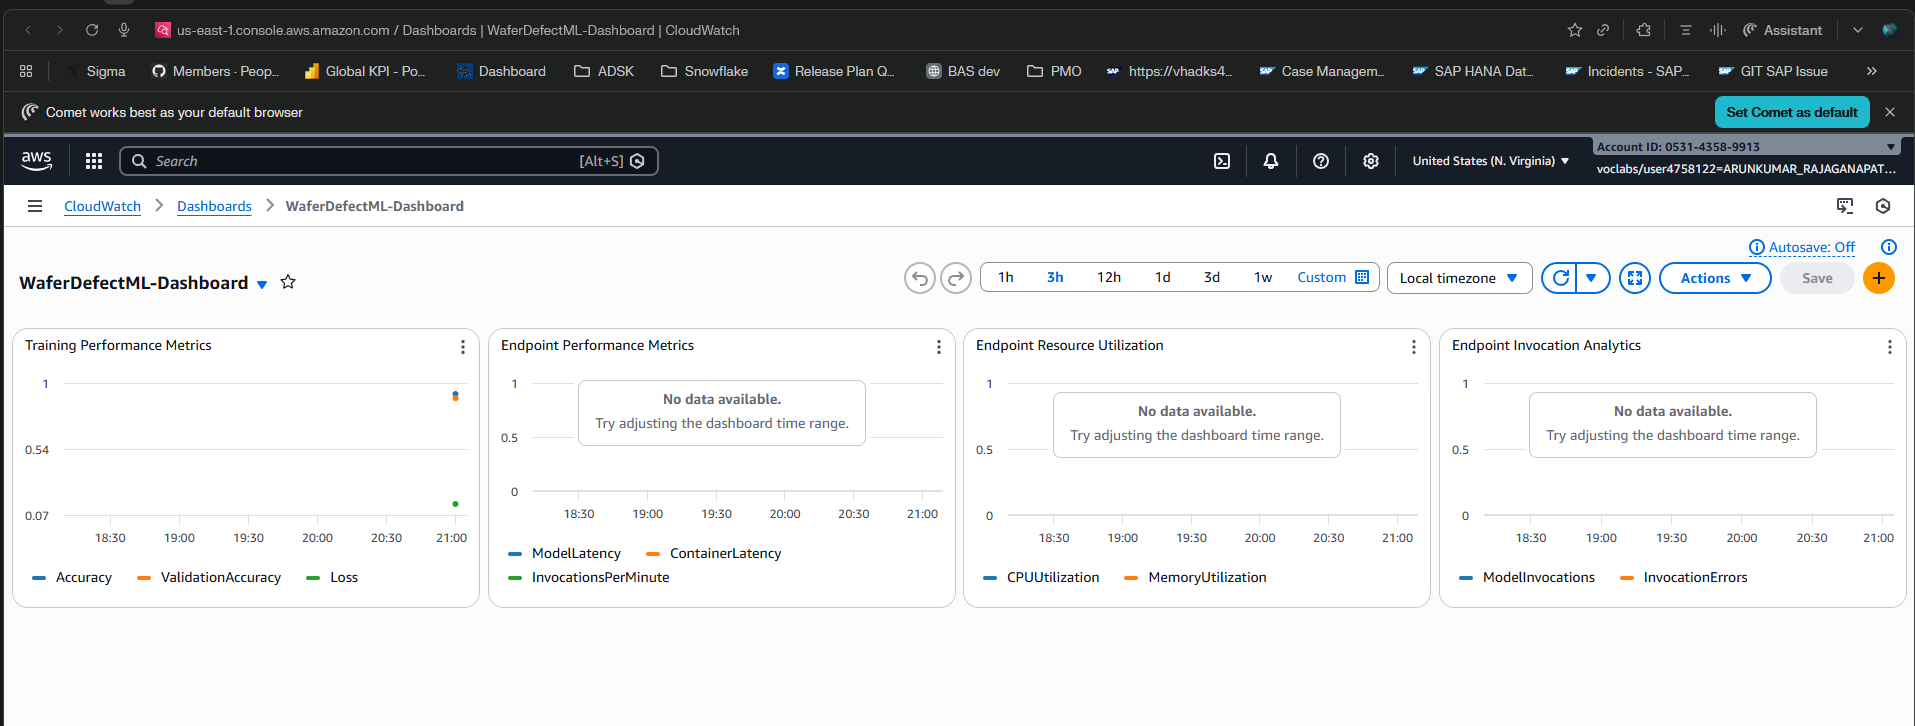

## 🔹 Step 6 – Query CloudWatch Metrics

Retrieve and analyze metrics from CloudWatch for trend analysis:

In [12]:
# Create CloudWatch Alarms for model and infrastructure monitoring
import boto3

# Ensure we have account_id, region, and endpoint_name available (fallbacks for local/testing runs)
try:
    account_id
except NameError:
    try:
        account_id = boto3.client('sts').get_caller_identity()['Account']
    except Exception:
        account_id = "123456789012"

try:
    region
except NameError:
    region = boto3.Session().region_name or "us-east-1"

try:
    endpoint_name
except NameError:
    endpoint_name = "wafer-defect-endpoint"

# Construct SNS topic ARN (replace with your real SNS topic to enable notifications)
sns_topic_arn = f"arn:aws:sns:{region}:{account_id}:ml-alerts"

alarms_config = [
    {
        'AlarmName': 'WaferML-LowModelAccuracy',
        'MetricName': 'Accuracy',
        'Namespace': 'WaferDefectML/Training',
        'Statistic': 'Average',
        'Period': 300,
        'EvaluationPeriods': 2,
        'Threshold': 0.85,
        'ComparisonOperator': 'LessThanThreshold',
        'AlarmDescription': 'Alert when training accuracy drops below 85%'
    },
    {
        'AlarmName': 'WaferML-HighEndpointLatency',
        'MetricName': 'ModelLatency',
        'Namespace': 'AWS/SageMaker',
        'Statistic': 'Average',
        'Period': 60,
        'EvaluationPeriods': 3,
        'Threshold': 200,
        'ComparisonOperator': 'GreaterThanThreshold',
        'AlarmDescription': 'Alert when endpoint latency exceeds 200ms'
    },
    {
        'AlarmName': 'WaferML-HighCPUUtilization',
        'MetricName': 'CPUUtilization',
        'Namespace': 'AWS/SageMaker',
        'Statistic': 'Average',
        'Period': 300,
        'EvaluationPeriods': 2,
        'Threshold': 80,
        'ComparisonOperator': 'GreaterThanThreshold',
        'AlarmDescription': 'Alert when endpoint CPU exceeds 80%'
    },
    {
        'AlarmName': 'WaferML-EndpointErrors',
        'MetricName': 'InvocationErrors',
        'Namespace': 'AWS/SageMaker',
        'Statistic': 'Sum',
        'Period': 300,
        'EvaluationPeriods': 1,
        'Threshold': 10,
        'ComparisonOperator': 'GreaterThanThreshold',
        'AlarmDescription': 'Alert when invocation errors exceed 10 in 5 minutes'
    }
]

print("Creating CloudWatch Alarms...\n")

created_alarms = []
for alarm in alarms_config:
    try:
        # Only add EndpointName dimension for AWS/SageMaker metrics
        dimensions = []
        if alarm['Namespace'] == 'AWS/SageMaker':
            dimensions = [{'Name': 'EndpointName', 'Value': endpoint_name}]

        cloudwatch.put_metric_alarm(
            AlarmName=alarm['AlarmName'],
            MetricName=alarm['MetricName'],
            Namespace=alarm['Namespace'],
            Statistic=alarm['Statistic'],
            Period=alarm['Period'],
            EvaluationPeriods=alarm['EvaluationPeriods'],
            Threshold=alarm['Threshold'],
            ComparisonOperator=alarm['ComparisonOperator'],
            AlarmDescription=alarm['AlarmDescription'],
            Dimensions=dimensions,
            # AlarmActions=[sns_topic_arn]  # Uncomment when you have a real SNS topic ARN
        )
        created_alarms.append(alarm['AlarmName'])
        print(f"✓ {alarm['AlarmName']}")
        print(f"  Condition: {alarm['MetricName']} {alarm['ComparisonOperator']} {alarm['Threshold']}")
        print()
    except Exception as e:
        print(f"⚠ Error creating {alarm['AlarmName']}: {e}\n")

print(f"Created {len(created_alarms)} alarms successfully")

Creating CloudWatch Alarms...

✓ WaferML-LowModelAccuracy
  Condition: Accuracy LessThanThreshold 0.85

✓ WaferML-HighEndpointLatency
  Condition: ModelLatency GreaterThanThreshold 200

✓ WaferML-HighCPUUtilization
  Condition: CPUUtilization GreaterThanThreshold 80

✓ WaferML-EndpointErrors
  Condition: InvocationErrors GreaterThanThreshold 10

Created 4 alarms successfully


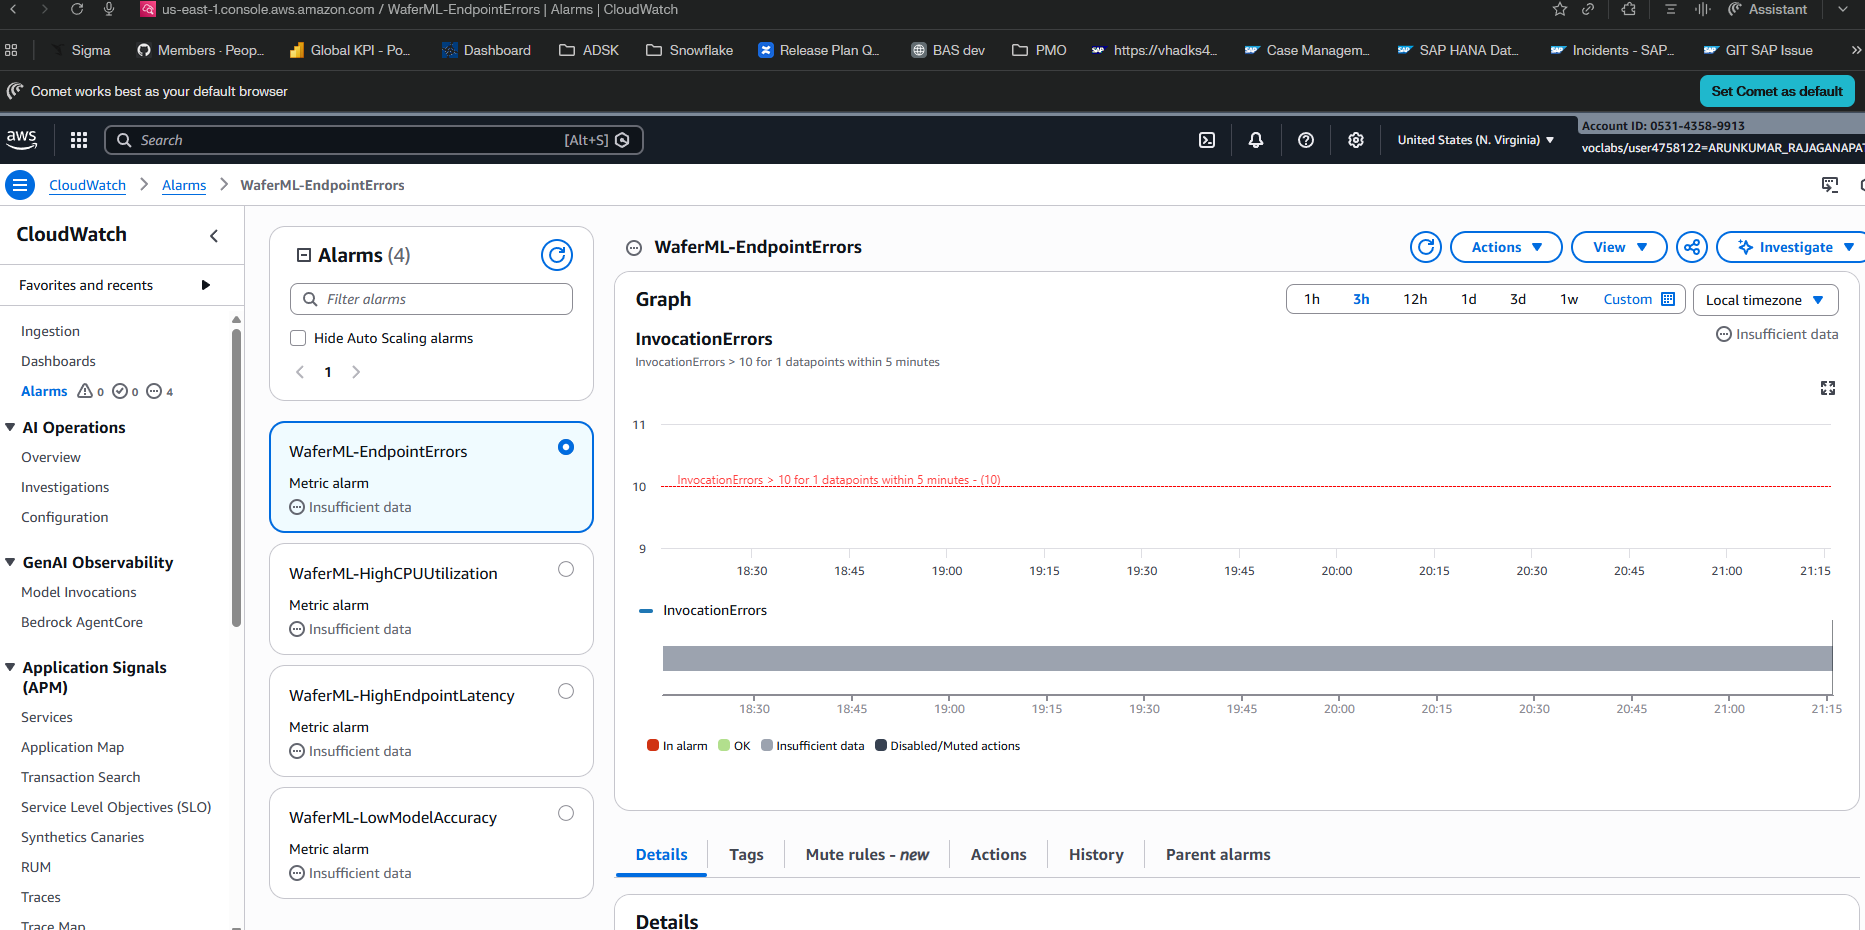

## ✅ SageMaker Studio & CloudWatch Monitoring Setup Complete

We have successfully:
- ✔ Configured CloudWatch client and SageMaker session
- ✔ Published custom training metrics to CloudWatch
- ✔ Monitored endpoint performance and resource utilization
- ✔ Created integrated CloudWatch dashboard
- ✔ Set up automated alarms for model and infrastructure
- ✔ Queried historical metrics for analysis

### 📊 Monitoring Components

**Training Metrics:**
- Model accuracy and validation accuracy
- Training loss and improvement trends
- Training duration and efficiency

**Endpoint Metrics:**
- Model latency and container latency
- Invocations per minute and error rates
- CPU and memory utilization
- Prediction accuracy tracking

**CloudWatch Dashboard:**
- 4-panel unified dashboard for all metrics
- Real-time visualization of performance
- Historical trend analysis
- Quick alarm status overview

### 🚨 Alarms Created

- **WaferML-LowModelAccuracy**: Triggers when accuracy < 85%
- **WaferML-HighEndpointLatency**: Triggers when latency > 200ms
- **WaferML-HighCPUUtilization**: Triggers when CPU > 80%
- **WaferML-EndpointErrors**: Triggers when errors > 10/5min

### 🔄 Monitoring Workflow

1. **Training Phase**
   - SageMaker automatically logs metrics to CloudWatch
   - Custom metrics published via boto3
   - Dashboard updates in real-time

2. **Deployment Phase**
   - Endpoint metrics captured at deployment
   - Model latency and throughput monitored
   - Resource utilization tracked

3. **Production Inference**
   - Real-time prediction monitoring
   - Error tracking and alerting
   - Performance degradation detection

4. **Alerting & Action**
   - CloudWatch alarms trigger SNS notifications
   - EventBridge integration for automated responses
   - SageMaker Model Monitor for drift detection

### 📈 Best Practices

- Set alarm thresholds based on SLAs
- Review dashboard daily during office hours
- Use CloudWatch Logs Insights for debugging
- Archive metrics to S3 for long-term analysis
- Integrate with MLflow for experiment tracking

### 🔗 Useful CloudWatch Links

- Dashboard: CloudWatch > Dashboards > WaferDefectML-Dashboard
- Metrics: CloudWatch > Metrics > WaferDefectML/Training
- Alarms: CloudWatch > Alarms > All Alarms
- Logs: CloudWatch > Log Groups > /aws/sagemaker/training-jobs